# Chapter 3: Networking Fundamentals for Security

> "The Internet is a network of networks, which means it is also a collection of all their
> misconfigured routers and unpatched switches." anonymous

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Describe the OSI model's seven layers and map each to common security mechanisms.
2. Explain the TCP/IP stack and the three-way handshake.
3. Identify the purpose and security implications of key protocols: DNS, HTTP/S, SMTP, FTP, SSH.
4. Compute subnets and CIDR notation and explain why segmentation improves security.
5. Describe how ARP, DHCP, and routing work and how they are abused.
6. Explain the difference between TCP and UDP and identify when each is used.
7. Describe the role of NAT, VPNs, and proxies in network security.
8. Analyse a basic Wireshark capture to identify protocols and extract artefacts.

## Key Terms

- **OSI model**: Open Systems Interconnection model; seven-layer reference model.
- **TCP/IP**: Transmission Control Protocol / Internet Protocol; the foundation of the internet.
- **Three-way handshake**: SYN, SYN-ACK, ACK sequence that establishes a TCP connection.
- **Port**: a 16-bit number that identifies an application-level endpoint.
- **DNS**: Domain Name System; resolves domain names to IP addresses.
- **ARP**: Address Resolution Protocol; maps IP addresses to MAC addresses on a LAN.
- **DHCP**: Dynamic Host Configuration Protocol; assigns IP configuration automatically.
- **NAT**: Network Address Translation; maps private addresses to public addresses.
- **VLAN**: Virtual LAN; logical segmentation of a network at layer 2.
- **BGP**: Border Gateway Protocol; routes traffic between autonomous systems on the internet.
- **TLS**: Transport Layer Security; encrypts application-layer traffic.
- **PCAP**: packet capture file format used by Wireshark and tcpdump.

---

## The OSI Model

The OSI model divides network communication into seven abstraction layers, each providing services
to the layer above and using services from the layer below. Its value for security practitioners
is that it identifies precisely where a given attack or control operates.

### Layer 1: Physical

The physical layer transmits raw bits over a medium: copper, fibre optic, or radio frequency. Physical
security (locked wiring closets, tamper-evident connectors) and physical attacks (cable tapping,
rogue access points) operate here. A rogue Ethernet tap can capture all traffic on a segment before
any higher-layer control has an opportunity to act.

### Layer 2: Data Link

The data link layer provides node-to-node delivery within a single network segment using MAC (Media
Access Control) addresses. Protocols include Ethernet, Wi-Fi (802.11), and PPP. Security controls
at layer 2 include:

#### ARP and Its Vulnerabilities

ARP is stateless and unauthenticated: any host can claim to own any IP address. ARP poisoning (or
ARP spoofing) exploits this by broadcasting false ARP replies, redirecting traffic through an attacker's
machine for man-in-the-middle interception. Dynamic ARP Inspection (DAI) on managed switches validates
ARP replies against a trusted binding table.

#### VLAN Segmentation

VLANs are logical network segments configured on a switch. A host on VLAN 10 cannot directly reach
VLAN 20 without passing through a router or layer-3 switch where access control lists can be applied.
VLAN hopping attacks exploit trunk port misconfiguration to escape a VLAN; proper trunk port
configuration and disabling the default VLAN on trunks mitigate this.

### Layer 3: Network

The network layer routes packets across multiple network segments using IP addresses. IPv4 uses 32-bit
addresses; IPv6 uses 128-bit addresses.

#### IP Addressing and CIDR

CIDR notation expresses an address and its prefix length together: 192.168.1.0/24 denotes addresses
192.168.1.0 through 192.168.1.255 (256 hosts, 254 usable). The prefix length determines the subnet
mask. Segmenting a network into smaller subnets limits broadcast domains and creates enforcement points
for firewalls and ACLs.

#### Routing and BGP Hijacking

BGP is the protocol that determines how traffic flows between autonomous systems (AS) on the internet.
BGP trusts route announcements without cryptographic verification by default; a misconfigured or
malicious AS can announce a more-specific prefix for IP space it does not own, redirecting traffic
(BGP hijacking). RPKI (Resource Public Key Infrastructure) adds cryptographic origin validation to
BGP and is being progressively deployed.

### Layers 4 Through 7

| Layer | Name | Key Protocols | Key Security Mechanisms |
|---|---|---|---|
| 4 Transport | TCP, UDP | Stateful firewalls, rate limiting, TLS |
| 5 Session | NetBIOS, RPC | Session tokens, authentication |
| 6 Presentation | TLS, SSL, encoding | Certificate validation, encryption |
| 7 Application | HTTP/S, DNS, SMTP | WAF, DKIM/SPF/DMARC, input validation |

---

## TCP/IP in Depth

### The TCP Three-Way Handshake

TCP establishes a reliable, connection-oriented session with a three-way handshake. The initiator
sends a SYN with a random Initial Sequence Number (ISN). The responder acknowledges with SYN-ACK,
selecting its own ISN. The initiator sends ACK to complete the connection.

#### SYN Flood Attack

A SYN flood overwhelms a server by sending SYN packets with spoofed source addresses and never
completing the handshake. The server allocates state for each half-open connection until its table
is exhausted and it cannot accept legitimate connections. SYN cookies mitigate this by encoding
connection state in the ISN so no per-connection memory is allocated until the handshake completes.

### TCP Versus UDP

TCP provides reliable, ordered, error-checked delivery with connection state. UDP provides fast,
connectionless, best-effort delivery with no guarantee of order or arrival. Security implications:
TCP state can be exhausted (connection-table attacks); UDP is used for amplification DDoS (DNS, NTP,
SSDP reflection) because a small query produces a large response sent to a spoofed victim address.

### Key Application Protocols and Their Security Properties

#### DNS

DNS resolves human-readable names to IP addresses using a hierarchical, distributed database.
Plain DNS (port 53 UDP/TCP) sends queries and responses in the clear, enabling eavesdropping and
DNS spoofing (cache poisoning). DNSSEC adds cryptographic signatures to resource records. DNS over
HTTPS (DoH) and DNS over TLS (DoT) encrypt the channel.

#### HTTP and HTTPS

HTTP (port 80) transmits content in the clear. HTTPS (port 443) wraps HTTP in TLS, providing
confidentiality, integrity, and server authentication. HSTS (HTTP Strict Transport Security) instructs
browsers to only use HTTPS for a domain, preventing protocol-downgrade attacks.

#### SMTP and Email Security

SMTP (port 25/587) transfers email. SPF (Sender Policy Framework) lists authorized sending servers.
DKIM (DomainKeys Identified Mail) adds a cryptographic signature to messages. DMARC ties SPF and
DKIM together and specifies what receivers should do with failing messages. Together these three
controls block most domain impersonation used in phishing.

#### SSH Versus Telnet

Telnet (port 23) transmits everything in the clear including credentials. SSH (port 22) encrypts
the session, authenticates the server with a host key, and supports key-based client authentication
that eliminates password exposure entirely. Telnet has no legitimate use in any modern network.

---

## Network Address Translation and Segmentation

### NAT and Its Security Properties

NAT maps many private addresses (RFC 1918: 10.x.x.x, 172.16-31.x.x, 192.168.x.x) to a smaller
pool of public addresses. NAT provides a modest privacy benefit by hiding internal topology from
external observers, but it is not a firewall: many NAT implementations allow all outbound connections
and track return traffic, so an attacker who gets code running inside the network can freely exfiltrate.

### VPNs and Tunnelling

A VPN creates an encrypted tunnel between endpoints, allowing remote users to access private network
resources as if locally connected. IPsec and WireGuard are protocol options. Zero-trust network access
(ZTNA) is progressively replacing traditional VPNs by evaluating each request rather than granting
broad network access once a VPN session is established.

---

## Why This Matters

Every offensive technique in the later chapters of this book, and every defensive control, operates at
a specific layer of the network stack. Misidentifying the layer leads to deploying the wrong control.
A practitioner who cannot read a packet capture, explain a three-way handshake, or compute a subnet
is missing the vocabulary needed to diagnose nearly any security event.

---

## News in Focus

BGP hijacking incidents have repeatedly redirected substantial portions of internet traffic through
unexpected autonomous systems, sometimes for minutes, sometimes for hours. In documented cases,
traffic for major financial institutions and internet infrastructure was rerouted through foreign ASes.
These incidents underscore that the internet's core routing protocol was designed for a cooperative
environment and requires cryptographic augmentation (RPKI) to be resilient against misbehaving nodes.

---


=== Subnet Calculator ===

  10.0.0.0/8
    Network        : 10.0.0.0
    Broadcast      : 10.255.255.255
    First host     : 10.0.0.1
    Last host      : 10.255.255.254
    Usable hosts   : 16777214
    Subnet mask    : 255.0.0.0

  192.168.1.0/24
    Network        : 192.168.1.0
    Broadcast      : 192.168.1.255
    First host     : 192.168.1.1
    Last host      : 192.168.1.254
    Usable hosts   : 254
    Subnet mask    : 255.255.255.0

  172.16.0.0/20
    Network        : 172.16.0.0
    Broadcast      : 172.16.15.255
    First host     : 172.16.0.1
    Last host      : 172.16.15.254
    Usable hosts   : 4094
    Subnet mask    : 255.255.240.0

  10.10.5.64/26
    Network        : 10.10.5.64
    Broadcast      : 10.10.5.127
    First host     : 10.10.5.65
    Last host      : 10.10.5.126
    Usable hosts   : 62
    Subnet mask    : 255.255.255.192


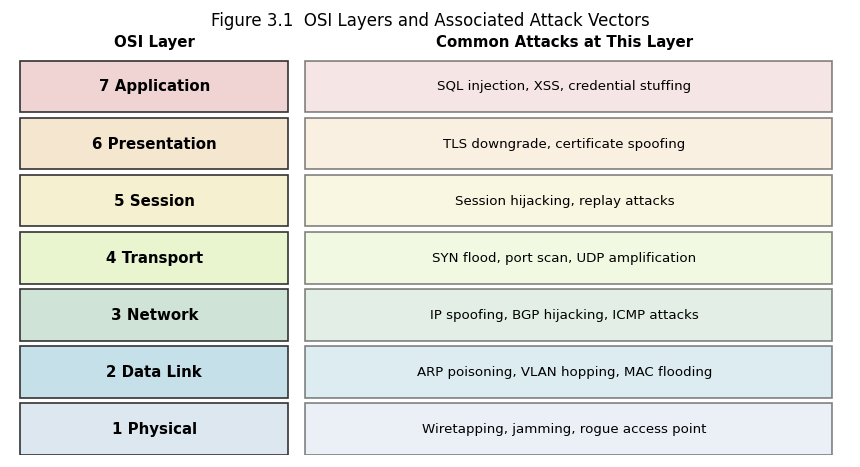

Figure 3.1 rendered.


In [1]:
# Chapter 3 -- Worked Example: Subnet calculator and protocol port reference
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import display, Image

# ── Subnet calculator ─────────────────────────────────────────────────────────
def subnet_info(cidr):
    addr, prefix = cidr.split('/')
    prefix = int(prefix)
    octets = list(map(int, addr.split('.')))
    mask_int = (0xFFFFFFFF << (32 - prefix)) & 0xFFFFFFFF
    addr_int = (octets[0]<<24)|(octets[1]<<16)|(octets[2]<<8)|octets[3]
    net_int = addr_int & mask_int
    bcast_int = net_int | (~mask_int & 0xFFFFFFFF)
    hosts = max(bcast_int - net_int - 1, 0)
    def i2s(i): return '.'.join(str((i>>s)&0xFF) for s in [24,16,8,0])
    return {
        'Network':    i2s(net_int),
        'Broadcast':  i2s(bcast_int),
        'First host': i2s(net_int+1) if hosts>0 else 'N/A',
        'Last host':  i2s(bcast_int-1) if hosts>0 else 'N/A',
        'Usable hosts': hosts,
        'Subnet mask':  i2s(mask_int),
    }

print("=== Subnet Calculator ===")
for cidr in ['10.0.0.0/8','192.168.1.0/24','172.16.0.0/20','10.10.5.64/26']:
    info = subnet_info(cidr)
    print(f"\n  {cidr}")
    for k, v in info.items():
        print(f"    {k:15}: {v}")

# ── OSI layer vs attack visual ────────────────────────────────────────────────
layers = [
    ("7 Application", "SQL injection, XSS, credential stuffing",       "#f0d4d4"),
    ("6 Presentation", "TLS downgrade, certificate spoofing",          "#f5e6d0"),
    ("5 Session",     "Session hijacking, replay attacks",             "#f5f0cf"),
    ("4 Transport",   "SYN flood, port scan, UDP amplification",       "#e8f5cf"),
    ("3 Network",     "IP spoofing, BGP hijacking, ICMP attacks",      "#cfe3d6"),
    ("2 Data Link",   "ARP poisoning, VLAN hopping, MAC flooding",     "#c5e0e8"),
    ("1 Physical",    "Wiretapping, jamming, rogue access point",      "#dde7f0"),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axis('off'); ax.set_xlim(0,10); ax.set_ylim(0, len(layers)*0.72+0.2)
for i, (label, attacks, color) in enumerate(reversed(layers)):
    y = i * 0.72
    ax.add_patch(plt.Rectangle((0.1,y), 3.2, 0.65, facecolor=color, edgecolor="#333", lw=1))
    ax.add_patch(plt.Rectangle((3.5,y), 6.3, 0.65, facecolor=color, edgecolor="#333", lw=1, alpha=0.6))
    ax.text(1.7, y+0.32, label, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(6.6, y+0.32, attacks, ha="center", va="center", fontsize=8)
ax.text(1.7, len(layers)*0.72+0.1, "OSI Layer", ha="center", fontsize=9, fontweight="bold")
ax.text(6.6, len(layers)*0.72+0.1, "Common Attacks at This Layer", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Figure 3.1  OSI Layers and Associated Attack Vectors", fontsize=10, pad=8)

_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 3.1 rendered.")


## Review Questions (MCQ)

**Q1.** ARP spoofing is primarily an attack at which OSI layer?
A. Layer 3  B. Layer 2  C. Layer 4  D. Layer 7

**Q2.** A SYN flood exploits which TCP mechanism?
A. Three-way handshake half-open state  B. Sequence number prediction  C. Port exhaustion  D. TTL expiry

**Q3.** DNS over HTTPS (DoH) protects against which threat?
A. Cache poisoning via DNS spoofing  B. DDoS via DNS amplification  C. DNS query eavesdropping  D. All of the above

**Q4.** Which RFC 1918 range provides the most host addresses?
A. 192.168.0.0/16  B. 172.16.0.0/12  C. 10.0.0.0/8  D. 100.64.0.0/10

**Q5.** A /26 subnet provides how many usable host addresses?
A. 62  B. 64  C. 30  D. 126

**Q6.** Which email security standard adds a cryptographic signature to message headers?
A. SPF  B. DMARC  C. DKIM  D. TLS

**Q7.** SSH differs from Telnet primarily in that SSH:
A. Uses port 22 vs port 23  B. Encrypts the session and authenticates the server  C. Requires a password  D. Works only on Unix

**Q8.** VLAN hopping attacks typically exploit misconfigured:
A. Router ACLs  B. Trunk ports  C. DHCP scopes  D. SNMP communities

**Q9.** BGP hijacking allows an attacker to:
A. Flood a network with packets  B. Redirect internet traffic by announcing illegitimate routes  C. Eavesdrop on TLS sessions  D. Crack Wi-Fi passwords

**Q10.** The RPKI standard is designed to mitigate:
A. ARP poisoning  B. DNS cache poisoning  C. BGP route hijacking  D. TCP SYN floods

*Answers: Q1 B, Q2 A, Q3 C, Q4 C, Q5 A, Q6 C, Q7 B, Q8 B, Q9 B, Q10 C.*

## Lab Assignment

**Part A -- Subnet design**: A company has the address block 10.10.0.0/16. Design subnets for five
departments (Finance 50 hosts, HR 30, Engineering 200, DMZ 10, Management 10). Document the network
address, broadcast, usable range, and mask for each subnet.

**Part B -- Packet analysis**: Capture 60 seconds of traffic on your local interface using Wireshark
or tcpdump (on a system you own or are authorised to analyse). Identify: the three most common
protocols by packet count, any cleartext protocols (HTTP, Telnet, FTP), and any DNS queries and their
responses. Document your methodology.

**Part C -- Protocol security matrix**: For each of DNS, HTTP, SMTP, FTP, and SSH, complete a table
with: port number, transport protocol (TCP/UDP), whether the protocol is encrypted by default, the
recommended secure alternative or configuration, and one attack that targets the protocol.

**Part D -- ARP investigation**: On a lab Linux VM, use `arp -a` to display the ARP cache. Use
`arping` or a similar tool to resolve a specific IP. Explain how an attacker running `arpspoof` would
modify this cache and what a defender would observe in the switch's MAC address table.

## References

```{bibliography}
:filter: docname in docnames
```
